## Local Volatility Model


The local volatility model is a deterministic volatility model where the volatility of an asset depends on both the underlying asset price and time. It extends the Black-Scholes model. It provides a better fit to observed market prices, for different strikes and maturities, by capturing the volatility smile, ensuring arbitrage-free pricing. The model is primarily used for exotic options pricing and volatility surface calibration, with the local volatility function derived using Dupire’s equation from market-implied volatilities.

The Local Volatility Model allows volatility to be a function of both time and moneyness  $\sigma_{loc}(S, t)$. It provides a way to construct a volatility surface directly from market option prices without assuming a specific stochastic process.

Key Advantages:

✅ Perfectly fits market-implied volatility surfaces (no model risk).

✅ Captures term structure and moneyness dependence of volatility.

✅ Better pricing of exotic options (barriers, cliquets, forward-start options).

### Theory: Dupire’s Local Volatility Formula

Given a set of market-implied volatilities  $\sigma_{imp}(K, T) $, Dupire’s formula allows us to compute the local volatility function  $\sigma_{loc}(S, t)$ :


$$\sigma_{loc}^2(K, T) = \frac{\frac{\partial C}{\partial T} + rK \frac{\partial C}{\partial K}}{\frac{1}{2} K^2 \frac{\partial^2 C}{\partial K^2}}$$


where:
- $C(K, T$)  is the market price of a European call with strike  K  and maturity  T .
- $\frac{\partial C}{\partial T}$  is the time derivative of the call price.
- $\frac{\partial C}{\partial K}$  and  $\frac{\partial^2 C}{\partial K^2}$  are the first and second derivatives with respect to strike.

🔹 Interpretation:
- This formula tells us how the implied volatility surface evolves locally at each point.
- The result is a non-parametric, arbitrage-free volatility model.

In [1]:
import numpy as np
import scipy.interpolate as interp
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt

def compute_local_vol(implied_vol_surface, strikes, maturities, risk_free_rate=0.02):
    """
    Computes local volatility using Dupire's equation.
    :param implied_vol_surface: 2D array of implied volatilities (rows: maturities, cols: strikes)
    :param strikes: Array of strike prices.
    :param maturities: Array of maturities.
    :param risk_free_rate: Constant risk-free rate.
    :return: 2D array of local volatilities.
    """
    # Ensure matrices are numpy arrays
    implied_vol_surface = np.array(implied_vol_surface)
    strikes = np.array(strikes)
    maturities = np.array(maturities)
    
    # Compute price surface assuming European call options (Black-Scholes formula inverted)
    prices = np.exp(-risk_free_rate * maturities[:, None]) * implied_vol_surface
    
    # Compute derivatives
    dC_dT = np.gradient(prices, maturities, axis=0, edge_order=2)
    dC_dK = np.gradient(prices, strikes, axis=1, edge_order=2)
    d2C_dK2 = np.gradient(dC_dK, strikes, axis=1, edge_order=2)
    
    # Apply Dupire's formula for local volatility
    local_vol = np.sqrt((dC_dT + risk_free_rate * strikes * dC_dK) / (0.5 * strikes**2 * d2C_dK2))
    
    return local_vol

### Generate synthetic data

/var/folders/bk/vr9m4cy108560n45r2h1hlh80000gn/T/ipykernel_38065/276171712.py:29: RuntimeWarning: invalid value encountered in sqrt
  local_vol = np.sqrt((dC_dT + risk_free_rate * strikes * dC_dK) / (0.5 * strikes**2 * d2C_dK2))


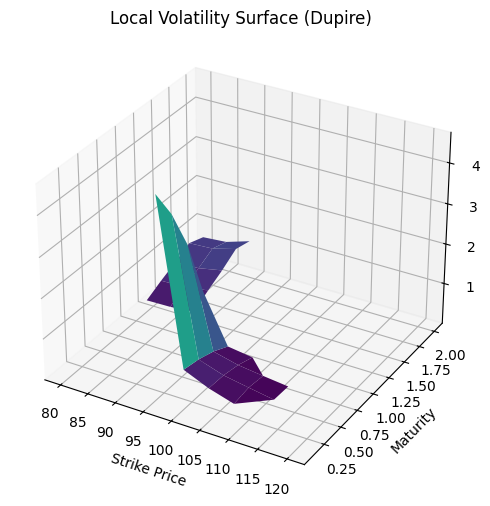

In [2]:
# Example Usage
strikes = np.linspace(80, 120, 10)
maturities = np.linspace(0.1, 2, 10)
# Example synthetic implied volatility surface
implied_vol_surface = 0.2 + 0.05 * np.exp(-0.5 * (strikes[:, None] - 100)**2 / 50) * np.exp(-0.5 * maturities**2 / 0.5)

local_vol_surface = compute_local_vol(implied_vol_surface, strikes, maturities)

# Plot the local volatility surface
X, Y = np.meshgrid(strikes, maturities)
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, local_vol_surface, cmap='viridis')
ax.set_xlabel('Strike Price')
ax.set_ylabel('Maturity')
ax.set_zlabel('Local Volatility')
ax.set_title('Local Volatility Surface (Dupire)')
plt.show()
